# SMT 공정 개선
* SMT(Surface Mount Technology)란?

    PCB에 구멍을 내지않고 칩을 직접 부착
    
* 사용 데이터: [AI Hub SMT 공정 개선 멀티모달 데이터](https://aihub.or.kr/aihubdata/data/view.do?pageIndex=1&currMenu=115&topMenu=100&srchOneDataTy=DATA006&srchOptnCnd=OPTNCND001&searchKeyword=&srchDetailCnd=DETAILCND001&srchOrder=ORDER001&srchPagePer=20&srchDataRealmCode=REALM012&aihubDataSe=data&dataSetSn=71900)

* SMT 공정 프로세스 설명: [(주)에이티에스로의 SMT 공정 절차 설명](https://blog.naver.com/atsro/221750964225)
    1. PCB 자동 로딩
    2. Solder Printing: 솔더를 PCB 표면상에 고르게 도포
       
       영향: 습도, 진동

    3. SPI(납'도포도'검사): 솔더가 고르게 잘 퍼졌는지 검사
    4. Chip Mounter: 부품을 흡착하여 PCB 위에 장착

       영향: 속도 $\rightarrow$ 저/중속 마운터 or 고속 마운터

    5. Reflow Soldering: 마운팅이 완료된 솔더를 경화시킴

       온도를 올리며 경화시킴.

       영행: 온도 (시간-구간마다 온도를 달리함)

    6. Unloading: PCB 적재 및 수납
    7. AOI(자동광학검사): 결함(외관) 검사 $\rightarrow$ 불량 시, 후공정
    

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from PIL import Image

In [2]:
DATA_ROOT = "./smt_data"

SENSOR_DATA_DIR = {
    'defect': os.path.join(DATA_ROOT, "Sample/01.원천데이터/센서데이터/사전공정/불량/1.미납"),
    'normal': os.path.join(DATA_ROOT, "Sample/01.원천데이터/센서데이터/사전공정/정상/1.미납")
}

IMAGE_DATA_DIR = {
    'defect': os.path.join(DATA_ROOT, "Sample/01.원천데이터/이미지데이터/사전공정/불량/1.미납"),
    'normal': os.path.join(DATA_ROOT, "Sample/01.원천데이터/이미지데이터/사전공정/정상/1.미납")
}

LABEL_DIR = os.path.join(DATA_ROOT, "Sample/02.라벨링데이터/사전공정/불량/1.미납")

In [3]:
def get_file_pairs(sensor_dir, image_dir):
    sensor_files = sorted([f for f in os.listdir(sensor_dir) if f.endswith('.xlsx')])
    pairs = []
    for sensor_file in sensor_files:
        base_name = sensor_file.replace('.xlsx', '')
        image_file = base_name + '.JPG'
        image_path = os.path.join(image_dir, image_file)
        sensor_path = os.path.join(sensor_dir, sensor_file)
        
        if os.path.exists(image_path):
            pairs.append({
                'base_name': base_name,
                'sensor_path': sensor_path,
                'image_path': image_path
            })
    return pairs

defect_pairs = get_file_pairs(SENSOR_DATA_DIR['defect'], IMAGE_DATA_DIR['defect'])
normal_pairs = get_file_pairs(SENSOR_DATA_DIR['normal'], IMAGE_DATA_DIR['normal'])

#### 이미지 하나 시각화

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

✓ 파일: PR_DEF_NM_A_20250807-092015_00002.json

🔴 주요 결함: 불량_미납
📊 결함 개수: 13개



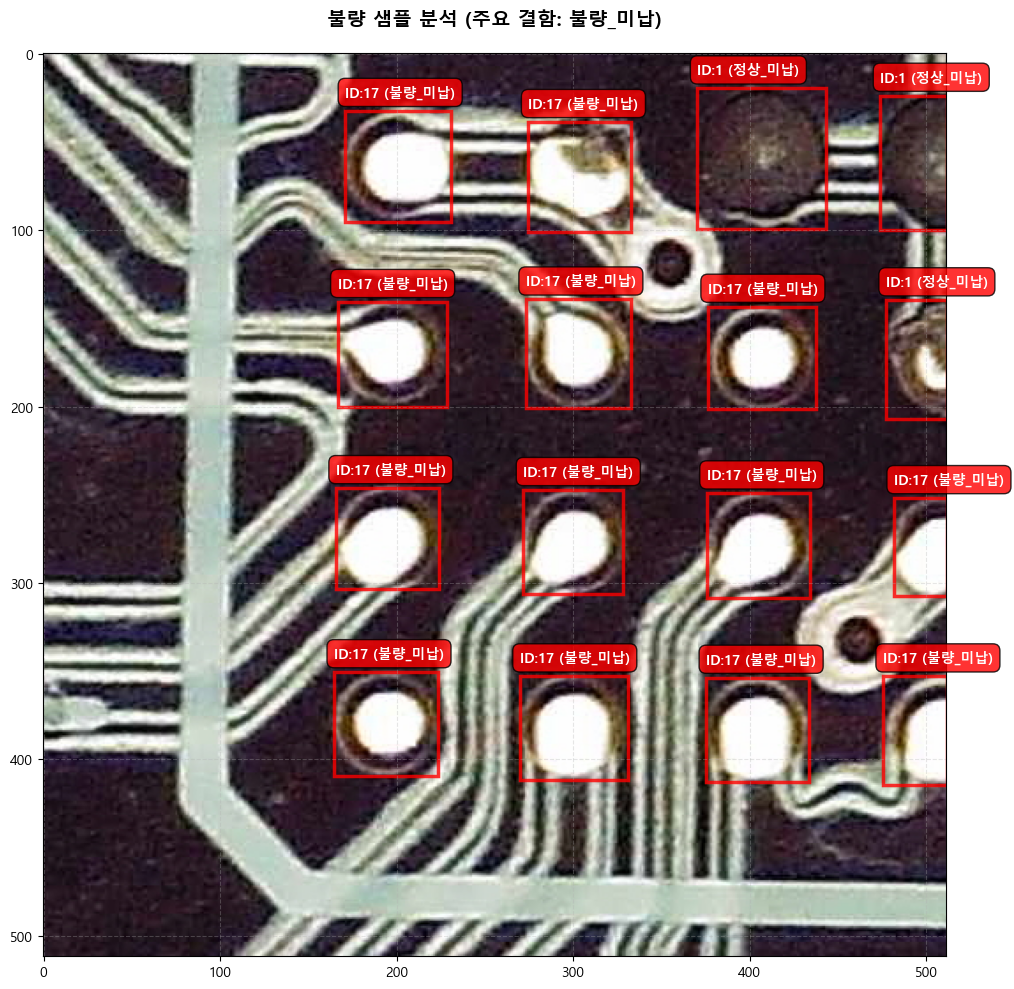


⏱️ 수집 기간: 2025-08-07 09:20:15 ~ 2025-08-07 09:20:19
📊 샘플 수: 5개



,timestamp,temperature,humidity,vibration,acceleration,noise,defect_detected
0,2025-08-07 09:20:15,24.38,52.04,0.3246,0.0401,70.38,1
1,2025-08-07 09:20:16,24.59,52.77,0.3394,0.0400,69.70,1
2,2025-08-07 09:20:17,24.73,53.04,0.3584,0.0404,69.31,1
3,2025-08-07 09:20:18,24.91,53.34,0.3708,0.0400,68.82,1
4,2025-08-07 09:20:19,25.10,54.00,0.3820,0.0400,68.50,1



📈 센서 통계:
  temperature: 24.7420 (범위: 24.3800~25.1000)
  humidity: 53.0380 (범위: 52.0400~54.0000)
  vibration: 0.3550 (범위: 0.3246~0.3820)
  acceleration: 0.0401 (범위: 0.0400~0.0404)
  noise: 69.3420 (범위: 68.5000~70.3800)


In [7]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import os
import pandas as pd
from collections import Counter
from pathlib import Path

DATA_ROOT = "./smt_data"
LABEL_DIR = Path(DATA_ROOT) / "Sample/02.라벨링데이터/사전공정/불량/1.미납"
IMAGE_DIR = Path(DATA_ROOT) / "Sample/01.원천데이터/이미지데이터/사전공정/불량/1.미납"

json_files = sorted(LABEL_DIR.glob("*.json"))
SAMPLE_JSON = json_files[1]

base_name = SAMPLE_JSON.stem
SAMPLE_IMAGE = IMAGE_DIR / f"{base_name}.JPG"

print(f"✓ 파일: {SAMPLE_JSON.name}\n")

with open(SAMPLE_JSON, 'r', encoding='utf-8') as f:
    data = json.load(f)

categories = {cat['id']: cat['name'] for cat in data['categories']}
img = Image.open(SAMPLE_IMAGE)
img_array = np.array(img)
img_width, img_height = img.size

defect_types = [categories[ann['category_id']] for ann in data['annotations'] 
               if '불량' in categories[ann['category_id']]]
main_defect = Counter(defect_types).most_common(1)[0][0] if defect_types else "결함 없음"

print(f"🔴 주요 결함: {main_defect}")
print(f"📊 결함 개수: {len(defect_types)}개\n")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(img_array)

for annotation in data['annotations']:
    x, y, w, h = annotation['bbox']
    category_id = annotation['category_id']
    category_name = categories[category_id]
    
    rect = patches.Rectangle((x, y), w, h, linewidth=2.5, 
                             edgecolor='red', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    
    text = f"ID:{category_id} ({category_name})"
    ax.text(x, y-8, text, fontsize=10, color='white', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.8))

ax.set_title(f"불량 샘플 분석 (주요 결함: {main_defect})", 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

sensor_df = pd.DataFrame(data['sensor_data'][0]['sensor_sequence'])

print(f"\n⏱️ 수집 기간: {sensor_df['timestamp'].min()} ~ {sensor_df['timestamp'].max()}")
print(f"📊 샘플 수: {len(sensor_df)}개\n")

display(sensor_df.round(4))

print("\n📈 센서 통계:")
for col in ['temperature', 'humidity', 'vibration', 'acceleration', 'noise']:
    print(f"  {col}: {sensor_df[col].mean():.4f} (범위: {sensor_df[col].min():.4f}~{sensor_df[col].max():.4f})")

In [8]:
# Cell 1
import json
import pandas as pd
from pathlib import Path
from collections import Counter

DATA_ROOT = "./smt_data"
LABEL_DIR = Path(DATA_ROOT) / "Sample/02.라벨링데이터/사전공정/불량/1.미납"

json_files = sorted(LABEL_DIR.glob("*.json"))
categories = None
all_defects = {}

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    if not categories:
        categories = {cat['id']: cat['name'] for cat in data['categories']}
    
    # 모든 annotation 중 불량_* 만 필터링
    defect_types = [categories[ann['category_id']] for ann in data['annotations'] 
                   if '불량' in categories[ann['category_id']]]
    
    # 불량이 없으면 스킵
    if not defect_types:
        continue
    
    main_defect = Counter(defect_types).most_common(1)[0][0]
    sensor_df = pd.DataFrame(data['sensor_data'][0]['sensor_sequence'])
    
    if main_defect not in all_defects:
        all_defects[main_defect] = {
            'temps': [], 'humids': [], 'vibs': [], 'noises': [], 'count': 0
        }
    
    all_defects[main_defect]['temps'].append(sensor_df['temperature'].mean())
    all_defects[main_defect]['humids'].append(sensor_df['humidity'].mean())
    all_defects[main_defect]['vibs'].append(sensor_df['vibration'].mean())
    all_defects[main_defect]['noises'].append(sensor_df['noise'].mean())
    all_defects[main_defect]['count'] += 1

print(f"✓ 분석 완료\n")


# Cell 2
print("="*70)
print("불량 타입별 센서 범위")
print("="*70 + "\n")

for defect_type in sorted(all_defects.keys()):
    stats = all_defects[defect_type]
    print(f"{defect_type} (n={stats['count']})")
    print(f"  온도: {min(stats['temps']):.2f}~{max(stats['temps']):.2f}°C")
    print(f"  습도: {min(stats['humids']):.2f}~{max(stats['humids']):.2f}%")
    print(f"  진동: {min(stats['vibs']):.4f}~{max(stats['vibs']):.4f}m/s²")
    print(f"  노이즈: {min(stats['noises']):.2f}~{max(stats['noises']):.2f}dB")
    print()

✓ 분석 완료

불량 타입별 센서 범위

불량_납형성불량 (n=2)
  온도: 25.08~25.95°C
  습도: 51.19~58.08%
  진동: 0.3394~0.5724m/s²
  노이즈: 70.74~71.06dB

불량_미납 (n=48)
  온도: 23.02~26.72°C
  습도: 40.53~76.71%
  진동: 0.2033~0.5980m/s²
  노이즈: 61.43~89.95dB



In [9]:
import json
import pandas as pd
from pathlib import Path

DATA_ROOT = "./smt_data"
NORMAL_LABEL_DIR = Path(DATA_ROOT) / "Sample/02.라벨링데이터/사전공정/정상/1.미납"

json_files = sorted(NORMAL_LABEL_DIR.glob("*.json"))

normal_sensors = {
    'temps': [], 'humids': [], 'vibs': [], 'accels': [], 'noises': []
}

for json_file in json_files:
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    sensor_df = pd.DataFrame(data['sensor_data'][0]['sensor_sequence'])
    
    normal_sensors['temps'].append(sensor_df['temperature'].mean())
    normal_sensors['humids'].append(sensor_df['humidity'].mean())
    normal_sensors['vibs'].append(sensor_df['vibration'].mean())
    normal_sensors['accels'].append(sensor_df['acceleration'].mean())
    normal_sensors['noises'].append(sensor_df['noise'].mean())

print("="*70)
print("정상 데이터 센서 범위")
print("="*70 + "\n")

print(f"온도: {min(normal_sensors['temps']):.2f}~{max(normal_sensors['temps']):.2f}°C (평균: {np.mean(normal_sensors['temps']):.2f})")
print(f"습도: {min(normal_sensors['humids']):.2f}~{max(normal_sensors['humids']):.2f}% (평균: {np.mean(normal_sensors['humids']):.2f})")
print(f"진동: {min(normal_sensors['vibs']):.4f}~{max(normal_sensors['vibs']):.4f}m/s² (평균: {np.mean(normal_sensors['vibs']):.4f})")
print(f"가속도: {min(normal_sensors['accels']):.4f}~{max(normal_sensors['accels']):.4f}g (평균: {np.mean(normal_sensors['accels']):.4f})")
print(f"노이즈: {min(normal_sensors['noises']):.2f}~{max(normal_sensors['noises']):.2f}dB (평균: {np.mean(normal_sensors['noises']):.2f})")

print(f"\n✓ {len(json_files)}개 파일 분석")

정상 데이터 센서 범위

온도: 23.05~26.92°C (평균: 24.96)
습도: 40.06~59.22% (평균: 49.93)
진동: 0.2020~0.4958m/s² (평균: 0.3456)
가속도: 0.0105~0.0399g (평균: 0.0250)
노이즈: 60.12~74.94dB (평균: 66.24)

✓ 50개 파일 분석
